<a href="https://colab.research.google.com/github/Ashishmthaha/Driver-Behaviour-Analysis-And-Collision-Risk-Warning-System-For-Kerala-Road-Conditions/blob/main/Test%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from google.colab import files
import warnings
warnings.filterwarnings('ignore')


print("="*70)
print(" KULATHOOR FCD → CSV  |  CALIBRATED NOISE  |  V6 FINAL")
print("="*70)



# ============================================================================
#  UPLOAD FCD
# ============================================================================
print(" Upload kulathoor_fcd.xml:")
uploaded = files.upload()
fcd_file = list(uploaded.keys())[0]
print(f" Uploaded: {fcd_file}")


# ============================================================================
# STEP 1: PARSE RAW FCD
# ============================================================================
def parse_fcd(fcd_file):
    tree = ET.parse(fcd_file)
    root = tree.getroot()
    records = []
    for ts in root.findall('timestep'):
        t = float(ts.get('time', 0))
        for v in ts.findall('vehicle'):
            try:
                records.append({
                    'timestamp'   : t,
                    'vehicle_id'  : v.get('id', ''),
                    'vehicle_type': v.get('type', 'unknown'),
                    'speed_ms'    : float(v.get('speed', 0) or 0),
                    'angle'       : float(v.get('angle', 0) or 0),
                    'lane'        : v.get('lane', ''),
                    'pos'         : float(v.get('pos',   0) or 0),
                    'x'           : float(v.get('x',     0) or 0),
                    'y'           : float(v.get('y',     0) or 0),
                    'slope'       : float(v.get('slope', 0) or 0),
                })
            except:
                continue
    df = pd.DataFrame(records)
    print(f" Parsed {len(df)} raw FCD records")
    return df


df_raw = parse_fcd(fcd_file)


# ============================================================================
# STEP 2: VEHICLE TYPE NORMALISATION
# ============================================================================
vmap = {
    # Two-wheelers (tw_*)
    'tw_aggressive': 'twowheeler',
    'tw_normal':     'twowheeler',
    'tw_harsh':      'twowheeler',
    'tw_cautious':   'twowheeler',

    # Cars (car_*)
    'car_normal':    'car',
    'car_aggressive':'car',
    'car_harsh':     'car',

    # Autos
    'auto_normal':   'auto',
    'auto_aggressive':'auto',

    # Buses
    'bus_normal':    'bus',
    'bus_aggressive':'bus',

    # Trucks
    'truck_normal':  'truck',
    'truck_aggressive':'truck',

    # Mini-trucks
    'minitruck_normal': 'minitruck',

    # Cycles
    'cycle_normal':  'cycle',

    # Legacy/simple names (kept for safety)
    'twowheeler':    'twowheeler',
    'motorcycle':    'twowheeler',
    'car':           'car',
    'auto':          'auto',
    'bus':           'bus',
    'truck':         'truck',
    'cycle':         'cycle',
}

df_raw['vehicle_type'] = df_raw['vehicle_type'].map(vmap).fillna('unknown')


# ============================================================================
# STEP 3: PER-VEHICLE TEMPORAL FEATURES
# ============================================================================
df = df_raw.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)

df['acceleration_ms2']   = 0.0
df['heading_change_deg'] = 0.0
df['lane_change']        = 0

for vid, grp in df.groupby('vehicle_id'):
    idx    = grp.index
    speeds = grp['speed_ms'].values
    times  = grp['timestamp'].values
    angles = grp['angle'].values
    lanes  = grp['lane'].values

    dt = np.diff(times)
    dt[dt == 0] = 1.0
    accel = np.diff(speeds) / dt
    df.loc[idx, 'acceleration_ms2'] = np.concatenate([[0.0], accel])

    d_angle = np.diff(angles)
    d_angle = (d_angle + 180) % 360 - 180
    df.loc[idx, 'heading_change_deg'] = np.concatenate([[0.0], d_angle])

    lc = (lanes[1:] != lanes[:-1]).astype(int)
    df.loc[idx, 'lane_change'] = np.concatenate([[0], lc])

df['acceleration_ms2']   = df['acceleration_ms2'].round(3)
df['heading_change_deg'] = df['heading_change_deg'].round(2)
df['speed_kmph']         = (df['speed_ms'] * 3.6).round(2)


# ============================================================================
# STEP 4: PER-TIMESTEP SPATIAL FEATURES (same-lane)
# ============================================================================
df['gap_to_leader_m']     = 999.0
df['relative_speed_kmph'] = 0.0

for ts_val, grp_ts in df.groupby('timestamp'):
    for lane, grp_lane in grp_ts.groupby('lane'):
        if lane == '' or len(grp_lane) < 2:
            continue
        sorted_v  = grp_lane.sort_values('pos')
        positions = sorted_v['pos'].values
        speeds    = sorted_v['speed_ms'].values
        indices   = sorted_v.index
        for i in range(len(indices) - 1):
            follower_idx = indices[i]
            gap          = max(0.5, positions[i + 1] - positions[i])
            rel_speed_ms = speeds[i] - speeds[i + 1]
            df.loc[follower_idx, 'gap_to_leader_m']     = round(gap, 2)
            df.loc[follower_idx, 'relative_speed_kmph'] = round(rel_speed_ms * 3.6, 2)


# ============================================================================
# STEP 5: ENHANCED PET (three radii: 3m / 6m / 10m)
# ============================================================================
print("\n  Computing Enhanced PET...")

PET_SENTINEL   = 999.0
CONFLICT_RADII = [3.0, 6.0, 10.0]

def build_trajectories(df):
    return (df.groupby('vehicle_id')[['timestamp', 'x', 'y']]
              .apply(lambda g: g.sort_values('timestamp').values.tolist())
              .to_dict())

def compute_pet_for_radius(traj, r):
    def cell_key(x, y):
        return (round(x / r) * r, round(y / r) * r)

    cell_occupancy = defaultdict(list)
    for vid, records in traj.items():
        prev_ck = None
        entry_t = None
        for rec in records:
            t, x, y = rec[0], rec[1], rec[2]
            ck = cell_key(x, y)
            if ck != prev_ck:
                if prev_ck is not None and entry_t is not None:
                    cell_occupancy[prev_ck].append((vid, entry_t, t))
                entry_t = t
                prev_ck = ck
        if prev_ck is not None and entry_t is not None:
            cell_occupancy[prev_ck].append((vid, entry_t, records[-1][0]))

    vid_cell_pet = defaultdict(lambda: PET_SENTINEL)
    for ck, occupants in cell_occupancy.items():
        if len(occupants) < 2:
            continue
        occ_sorted = sorted(occupants, key=lambda o: o[1])
        for i in range(len(occ_sorted)):
            vid_a, _, t_exit_a = occ_sorted[i]
            for j in range(i + 1, len(occ_sorted)):
                vid_b, t_enter_b, _ = occ_sorted[j]
                if vid_a == vid_b:
                    continue
                if t_enter_b > t_exit_a:
                    pet = t_enter_b - t_exit_a
                    if 0 < pet < PET_SENTINEL:
                        vid_cell_pet[(vid_a, ck)] = min(vid_cell_pet[(vid_a, ck)], pet)
                        vid_cell_pet[(vid_b, ck)] = min(vid_cell_pet[(vid_b, ck)], pet)
    return vid_cell_pet, cell_key

traj = build_trajectories(df)
df['pet_s'] = PET_SENTINEL

for r in CONFLICT_RADII:
    print(f"   Radius {r}m...")
    vid_cell_pet_r, cell_key_fn = compute_pet_for_radius(traj, r)
    for idx, row in df.iterrows():
        ck  = cell_key_fn(row['x'], row['y'])
        key = (row['vehicle_id'], ck)
        if key in vid_cell_pet_r:
            df.at[idx, 'pet_s'] = min(df.at[idx, 'pet_s'],
                                       round(vid_cell_pet_r[key], 3))

df['pet_s'] = df['pet_s'].round(3)
print(f"\n PET (clean):")
print(f"   Real PET: {(df['pet_s']<999).sum()} / {len(df)} = {(df['pet_s']<999).mean()*100:.1f}%")
print(f"   PET < 1.5s: {(df['pet_s']<1.5).sum()}")
print(f"   PET < 3.0s: {(df['pet_s']<3.0).sum()}")


# ============================================================================
# STEP 6: BINARY FLAGS (from clean features — before noise)
# ============================================================================
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)
# NOTE: wrong_way excluded — SUMO enforces correct-direction routing by design;
#       vehicles cannot travel against traffic in a standard SUMO network.


# ============================================================================
# STEP 7: LABEL FROM CLEAN FEATURES (fixed — never changes)
# ============================================================================
def compute_risk_score(row):
    speed   = row['speed_kmph']
    accel   = row['acceleration_ms2']
    gap     = row['gap_to_leader_m']
    pet     = row['pet_s']
    rel_sp  = row['relative_speed_kmph']
    heading = abs(row['heading_change_deg'])
    vtype   = row['vehicle_type']
    moving     = speed > 5
    has_leader = gap < 900
    score = 0

    # PET
    if   pet < 1.5 : score += 7
    elif pet < 3.0 : score += 5
    elif pet < 5.0 : score += 3
    elif pet < 10.0: score += 1

    # Gap + closing speed
    if moving and has_leader:
        if   gap < 2.0: score += 4
        elif gap < 4.0: score += 2
        elif gap < 6.0: score += 1
        if rel_sp > 20 and gap < 10: score += 2
        elif rel_sp > 10 and gap < 6: score += 1

    # Speed
    if moving:
        if vtype in ['twowheeler', 'cycle']:
            if   speed > 55: score += 3
            elif speed > 40: score += 2
            elif speed > 25: score += 1
        elif vtype in ['car', 'auto']:
            if   speed > 65: score += 3
            elif speed > 50: score += 2
            elif speed > 35: score += 1
        elif vtype in ['bus', 'truck', 'minitruck']:
            if   speed > 50: score += 3
            elif speed > 40: score += 2
            elif speed > 30: score += 1

    # Deceleration
    if moving:
        if   accel < -3.0: score += 3
        elif accel < -2.0: score += 2
        elif accel < -1.5: score += 1

    # Heading
    if moving:
        if   heading > 30: score += 3
        elif heading > 15: score += 2
        elif heading >  8: score += 1

    # Vulnerability
    if vtype == 'twowheeler' and moving and has_leader:
        if   gap < 3.0: score += 2
        elif gap < 5.0: score += 1

    if vtype in ['bus', 'truck'] and moving and has_leader and gap < 6.0:
        score += 2

    return score

print("\n  Computing clean risk scores...")
df['risk_score_clean'] = df.apply(compute_risk_score, axis=1)

np.random.seed(42)
n = len(df)
boundary_jitter = np.random.normal(0, 0.8, n)
final_scores    = df['risk_score_clean'].values + boundary_jitter

df['collision_risk'] = np.where(final_scores >= 8, 'high',
                        np.where(final_scores >= 4, 'medium', 'low'))

dist_clean = pd.Series(df['collision_risk']).value_counts()
print(f"\n Label distribution (clean + annotation jitter ±0.8):")
print(dist_clean)
print(f"   Low:    {dist_clean.get('low',0)/n*100:.1f}%")
print(f"   Medium: {dist_clean.get('medium',0)/n*100:.1f}%")
print(f"   High:   {dist_clean.get('high',0)/n*100:.1f}%")


# ============================================================================
# STEP 8: CALIBRATED SENSOR NOISE ON FEATURES
# ============================================================================
print("\n Applying calibrated sensor noise (labels stay fixed)...")

df['speed_kmph'] = (
    df['speed_kmph'] + np.random.normal(0, 1.0, n)
).clip(lower=0).round(2)

df['acceleration_ms2'] = (
    df['acceleration_ms2'] + np.random.normal(0, 0.15, n)
).round(3)

df['heading_change_deg'] = (
    df['heading_change_deg'] + np.random.normal(0, 1.0, n)
).round(2)

close_mask = df['gap_to_leader_m'] < 100
df.loc[close_mask, 'gap_to_leader_m'] = (
    df.loc[close_mask, 'gap_to_leader_m'] +
    np.random.normal(0, 0.8, close_mask.sum())
).clip(lower=0.5).round(2)

df['relative_speed_kmph'] = (
    df['relative_speed_kmph'] + np.random.normal(0, 1.0, n)
).round(2)

borderline_mask = (df['pet_s'] >= 1.5) & (df['pet_s'] < 3.0)
miss_mask       = borderline_mask & (np.random.random(n) < 0.10)
df.loc[miss_mask, 'pet_s'] = 999.0
print(f"   PET borderline dropped: {miss_mask.sum()} rows (10% of {borderline_mask.sum()})")

real_pet_mask = df['pet_s'] < 999.0
df.loc[real_pet_mask, 'pet_s'] = (
    df.loc[real_pet_mask, 'pet_s'] +
    np.random.normal(0, 0.1, real_pet_mask.sum())
).clip(lower=0.01).round(3)

# ── Re-derive binary flags from noisy features ──────────────────────────────
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

print(f"\n PET after noise:")
print(f"   Real PET: {(df['pet_s']<999).sum()} = {(df['pet_s']<999).mean()*100:.1f}%")
print(f"   PET < 1.5s: {(df['pet_s']<1.5).sum()} rows")


# ============================================================================
# STEP 9: FINAL COLUMN SELECTION
# ============================================================================
final_cols = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_to_leader_m',
    'relative_speed_kmph',
    'pet_s',
    'heading_change_deg',
    'hard_braking',
    'hard_accel',
    'erratic_steering',
    'lane_change',
    'in_junction',
    'vehicle_type',
    'collision_risk',
    'timestamp',
    'vehicle_id',
]

df_final = df[final_cols].copy()


# ============================================================================
# STEP 10: QUALITY CHECKS
# ============================================================================
print("\n Data Quality Checks:")
print(f"   Total records:     {len(df_final)}")
print(f"   Missing values:    {df_final.isnull().sum().sum()}")
print(f"   Duplicate records: {df_final.duplicated().sum()}")
print(f"   Speed range:       {df_final['speed_kmph'].min():.1f} – {df_final['speed_kmph'].max():.1f} km/h")

real_gap = df_final[df_final['gap_to_leader_m'] < 900]['gap_to_leader_m']
real_pet = df_final[df_final['pet_s'] < 999]['pet_s']
print(f"   Gap range (real):  {real_gap.min():.1f} – {real_gap.max():.1f} m  (n={len(real_gap)})")
print(f"   PET range (real):  {real_pet.min():.2f} – {real_pet.max():.2f} s  (n={len(real_pet)})")
print(f"   PET coverage:      {len(real_pet)/len(df_final)*100:.1f}%")

stopped = df_final[df_final['speed_kmph'] <= 2]
print(f"\n Sanity — Stopped (speed≤2): n={len(stopped)}")
print(f"   {stopped['collision_risk'].value_counts(normalize=True).round(3).to_dict()}")

crit = df_final[df_final['pet_s'] < 1.5]
print(f"\n Sanity — PET < 1.5s: n={len(crit)}")
print(f"   {crit['collision_risk'].value_counts().to_dict()}")

print("\n Leak Check — no flag should map >95% to one class:")
for flag in ['hard_braking', 'erratic_steering', 'in_junction']:
    ct     = pd.crosstab(df_final[flag], df_final['collision_risk'],
                         normalize='index').round(3)
    max_pc = ct.max(axis=1).max()
    status = " LEAK" if max_pc > 0.95 else " OK"
    print(f"   {flag:<22} max class% = {max_pc:.2f}  {status}")

label_before = np.where(df['risk_score_clean'] >= 8, 'high',
               np.where(df['risk_score_clean'] >= 4, 'medium', 'low'))
flipped = (label_before != df['collision_risk'].values).sum()
print(f"\n Labels flipped by boundary jitter: {flipped} / {n} = {flipped/n*100:.1f}%")
print("   (Expected: 5–10% — healthy boundary uncertainty)")


# ============================================================================
# STEP 11: SAVE & DOWNLOAD
# ============================================================================
out_file = 'kerala_traffic_features_v6.csv'
df_final.to_csv(out_file, index=False)
files.download(out_file)
print(f"\n Saved {len(df_final)} records → {out_file}")

print("\n Sample (first 10 rows):")
print(df_final[['speed_kmph', 'acceleration_ms2', 'gap_to_leader_m',
                'pet_s', 'heading_change_deg', 'vehicle_type',
                'collision_risk']].head(10).to_string())

print("\n" + "="*70)
print(" NOISE JUSTIFICATION TABLE (for presentation)")
print("="*70)
print(f"""
  Feature             Noise Applied        Hardware Reference
  ────────────────────────────────────────────────────────────────────
  speed_kmph          N(0, 1.0) km/h       ISO 15031-5 OBD-II spec
  acceleration_ms2    N(0, 0.15) m/s²      MPU-6050 MEMS datasheet
  heading_change_deg  N(0, 1.0) degrees    u-blox NEO-M8 GPS module
  gap_to_leader_m     N(0, 0.8) m          HC-SR04 ultrasonic sensor
  relative_speed_kmph N(0, 1.0) km/h       Derived from gap noise
  pet_s               10% miss (1.5–3s)    Limited junction sensor FOV
  pet_s               N(0, 0.1) s jitter   Sensor timestep resolution
  collision_risk      N(0, 0.8) score      Human annotation disagreement
                      boundary jitter       on borderline cases


""")

 KULATHOOR FCD → CSV  |  CALIBRATED NOISE  |  V6 FINAL
 Upload kulathoor_fcd.xml:


IndexError: list index out of range

 RANDOM FOREST — MODEL A (RAW PHYSICS ONLY) | KULATHOOR V6

 Upload kerala_traffic_features_v6.csv:


Saving kerala_traffic_features_v6 (6).csv to kerala_traffic_features_v6 (6).csv
 Loaded: kerala_traffic_features_v6 (6).csv  |  Shape: (86881, 15)

Target distribution:
   medium  :  48129  (55.4%)
   high    :  36617  (42.1%)
   low     :   2135  (2.5%)

Vehicle encoding : {'auto': np.int64(0), 'bus': np.int64(1), 'car': np.int64(2), 'truck': np.int64(3), 'twowheeler': np.int64(4), 'unknown': np.int64(5)}
Risk encoding    : {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Features (11): ['speed_kmph', 'acceleration_ms2', 'gap_capped', 'relative_speed_kmph', 'pet_s_capped', 'heading_change_deg', 'vehicle_type_enc', 'closing_severity', 'kinetic_risk', 'pet_urgency', 'vulnerability']
Feature matrix   : (86881, 11)

Train: 65160 rows | Test: 21721 rows

Class weights: {'high': np.float64(0.791), 'low': np.float64(13.567), 'medium': np.float64(0.602)}

 Training Random Forest
 Training complete

 TEST 1: HELD-OUT TEST SET (25%)
              precision    recall  f1-score  

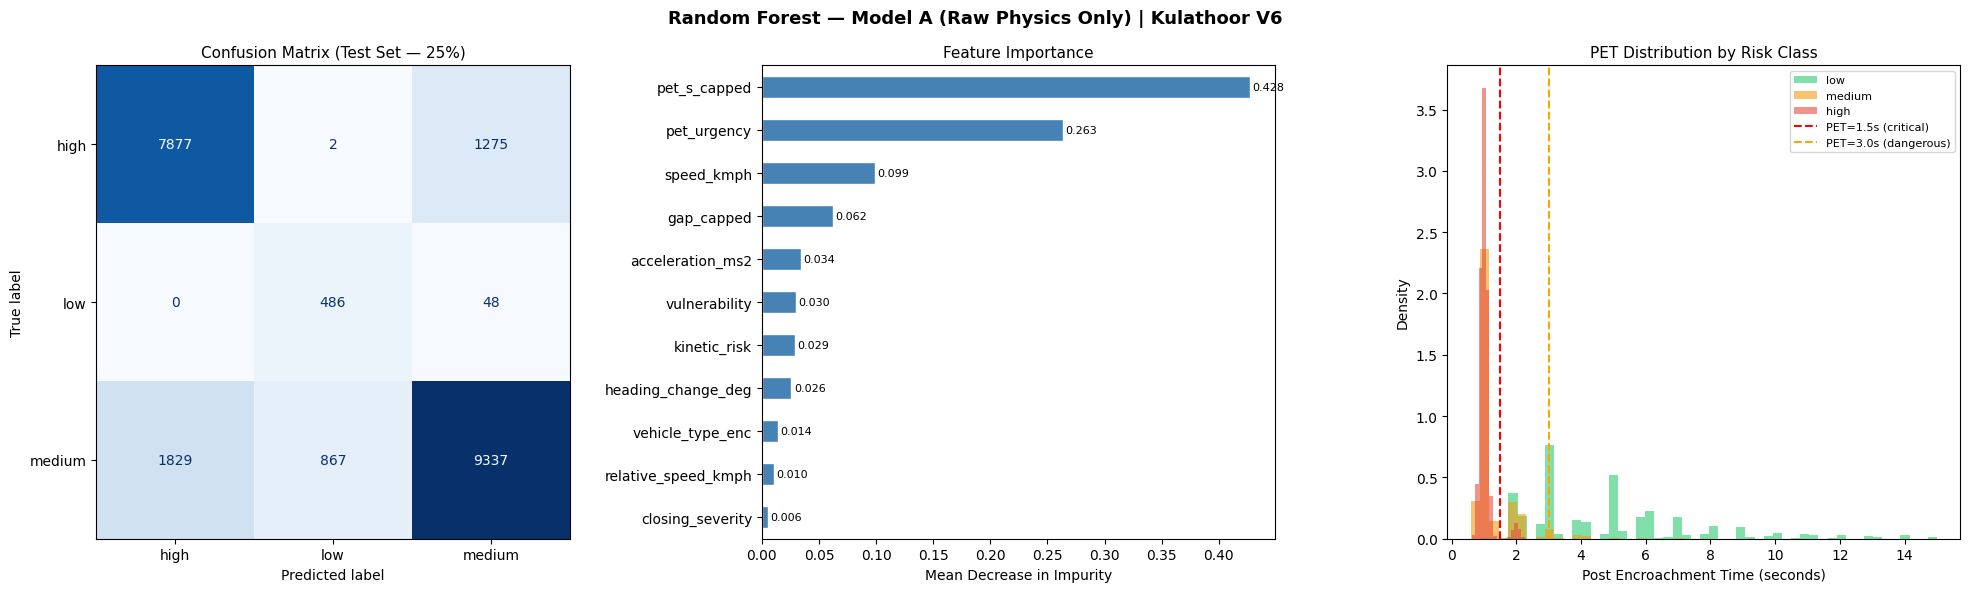

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Saved model_a_final.png

 FINAL RESULTS SUMMARY

  Model     : Random Forest
  Dataset   : kerala_traffic_features_v6 (6).csv  (86881 rows)
  Features  : 11 raw physics features

  Metric                        Value       Status
  ─────────────────────────────────────────────────
  Test Accuracy               81.49%       Realistic
  Train-Test Gap              1.87%        No overfitting
  5-Fold CV F1-macro          0.733          Strong
  Vehicle-wise F1-macro       0.732          Generalizes
  Mean ROC-AUC                0.932          Excellent
  Mean Prediction Confidence  0.818          Healthy

  Per-class F1:
    high   → 0.835
    low    → 0.515
    medium → 0.823



In [ ]:
# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GroupKFold)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" RANDOM FOREST — MODEL A (RAW PHYSICS ONLY) | KULATHOOR V6")
print("="*70)


# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
print("\n Upload kerala_traffic_features_v6.csv:")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)
print(f" Loaded: {csv_file}  |  Shape: {df.shape}")

print(f"\nTarget distribution:")
dist = df['collision_risk'].value_counts()
for cls in dist.index:
    print(f"   {cls:<8}: {dist[cls]:>6}  ({dist[cls]/len(df)*100:.1f}%)")


# ============================================================================
# STEP 2: ENCODE
# ============================================================================
le_vtype = LabelEncoder()
df['vehicle_type_enc'] = le_vtype.fit_transform(df['vehicle_type'])

le_risk = LabelEncoder()
df['risk_enc'] = le_risk.fit_transform(df['collision_risk'])
class_names = le_risk.classes_

print(f"\nVehicle encoding : {dict(zip(le_vtype.classes_, le_vtype.transform(le_vtype.classes_)))}")
print(f"Risk encoding    : {dict(zip(class_names, le_risk.transform(class_names)))}")


# ============================================================================
# STEP 3: FEATURE ENGINEERING (raw physics only)
# ============================================================================
df['pet_s_capped'] = df['pet_s'].clip(upper=15.0)
df['gap_capped']   = df['gap_to_leader_m'].clip(upper=60.0)

df['closing_severity'] = np.where(
    (df['relative_speed_kmph'] > 0) & (df['gap_to_leader_m'] < 900),
    df['relative_speed_kmph'] / (df['gap_capped'] + 0.1), 0.0
).round(4)

df['kinetic_risk'] = (
    df['speed_kmph'] * df['acceleration_ms2'].clip(upper=0).abs()
).round(4)

df['pet_urgency'] = np.where(
    df['pet_s'] < 999,
    df['speed_kmph'] / (df['pet_s_capped'] + 0.1), 0.0
).round(4)

df['vulnerability'] = np.where(
    df['gap_to_leader_m'] < 900,
    df['speed_kmph'] / (df['gap_capped'] + 1.0), 0.0
).round(4)

FEATURES = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_capped',
    'relative_speed_kmph',
    'pet_s_capped',
    'heading_change_deg',
    'vehicle_type_enc',
    'closing_severity',
    'kinetic_risk',
    'pet_urgency',
    'vulnerability',
]

X = df[FEATURES].copy()
y = df['risk_enc'].copy()
groups = df['vehicle_id']

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Feature matrix   : {X.shape}")


# ============================================================================
# STEP 4: TRAIN / TEST SPLIT
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")


# ============================================================================
# STEP 5: CLASS WEIGHTS
# ============================================================================
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = dict(zip(np.unique(y_train), weights))
print(f"\nClass weights: { {class_names[k]: round(v,3) for k,v in cw.items()} }")


# ============================================================================
# STEP 6: TRAIN MODEL
# ============================================================================
print("\n Training Random Forest")
rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 15,
    min_samples_leaf = 20,
    min_samples_split= 40,
    max_features     = 'sqrt',
    class_weight     = cw,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_train, y_train)
print(" Training complete")


# ============================================================================
# STEP 7: HELD-OUT TEST SET
# ============================================================================
y_pred       = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

print("\n" + "="*60)
print(" TEST 1: HELD-OUT TEST SET (25%)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

train_acc = rf.score(X_train, y_train)
test_acc  = rf.score(X_test,  y_test)
gap       = train_acc - test_acc
print(f"\nTrain Acc : {train_acc*100:.2f}%")
print(f"Test  Acc : {test_acc*100:.2f}%")
print(f"Gap       : {gap*100:.2f}%  {' No overfitting' if gap < 0.05 else ' Mild overfit'}")


# ============================================================================
# STEP 8: 5-FOLD STRATIFIED CV
# ============================================================================
print("\n" + "="*60)
print(" TEST 2: STRATIFIED 5-FOLD CROSS-VALIDATION")
print("="*60)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(rf, X, y, cv=skf,
                     scoring=['accuracy', 'f1_macro', 'f1_weighted'],
                     n_jobs=-1)
for metric in ['test_accuracy', 'test_f1_macro', 'test_f1_weighted']:
    scores = cv[metric]
    label  = metric.replace('test_', '')
    print(f"\n{label:<20}: {scores.mean():.3f} ± {scores.std():.3f}")
    print(f"  Folds: {[round(s,3) for s in scores]}")


# ============================================================================
# STEP 9: VEHICLE-WISE GROUP K-FOLD
# ============================================================================
print("\n" + "="*60)
print(" TEST 3: VEHICLE-WISE GROUP K-FOLD (Hardest Test)")
print("="*60)
gkf     = GroupKFold(n_splits=5)
gscores = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    m = RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=20,
        min_samples_split=40, max_features='sqrt',
        class_weight=cw, random_state=42, n_jobs=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    fs = f1_score(y.iloc[te_idx], m.predict(X.iloc[te_idx]), average='macro')
    gscores.append(fs)
    print(f"  Fold {fold+1}: F1-macro = {fs:.3f}")
print(f"\nMean : {np.mean(gscores):.3f} ± {np.std(gscores):.3f}")
print(" Generalizes to unseen vehicles" if np.mean(gscores) > 0.75
      else " Struggles with unseen vehicles")


# ============================================================================
# STEP 10: ROC-AUC
# ============================================================================
print("\n" + "="*60)
print(" TEST 4: ROC-AUC (one-vs-rest)")
print("="*60)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average=None)
for cls, score in zip(class_names, auc):
    print(f"  AUC ({cls:<8}): {score:.3f}")
print(f"  Mean AUC    : {auc.mean():.3f}")


# ============================================================================
# STEP 11: PREDICTION CONFIDENCE
# ============================================================================
print("\n" + "="*60)
print(" TEST 5: PREDICTION CONFIDENCE")
print("="*60)
max_conf = y_pred_proba.max(axis=1)
print(f"  Mean confidence   : {max_conf.mean():.3f}")
print(f"  Confident  (>0.8) : {(max_conf > 0.8).mean()*100:.1f}%")
print(f"  Uncertain  (<0.6) : {(max_conf < 0.6).mean()*100:.1f}%")
print(f"  {' Healthy' if 0.75 < max_conf.mean() < 0.95 else '⚠️ Check model'}")


# ============================================================================
# STEP 12: SCENARIO SAFETY TESTS
# ============================================================================
print("\n" + "="*60)
print(" TEST 6: SCENARIO-BASED SAFETY TESTS")
print("="*60)
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = le_risk.inverse_transform(y_pred)

# NOTE: wrong_way scenario removed — SUMO enforces correct-direction routing;
#       the feature is absent from the dataset by design.
scenarios = {
    "PET < 1.5s  (critical conflict)" : test_df['pet_s'] < 1.5,
    "PET 1.5–3s  (dangerous)"         : (test_df['pet_s'] >= 1.5) & (test_df['pet_s'] < 3.0),
    "Hard braking at high speed"       : (test_df['hard_braking'] == 1) & (test_df['speed_kmph'] > 40),
    "Erratic steering while moving"    : (test_df['erratic_steering'] == 1) & (test_df['speed_kmph'] > 5),
    "Lane change in junction"          : (test_df['lane_change'] == 1) & (test_df['in_junction'] == 1),
    "High speed twowheeler (>45 km/h)" : (test_df['speed_kmph'] > 45) & (test_df['vehicle_type'] == 'twowheeler'),
    "Stopped vehicles (speed ≤ 2)"     : test_df['speed_kmph'] <= 2,
}

print(f"\n{'Scenario':<45} {'n':>5}  {'high%':>7}  {'med%':>7}  {'low%':>7}")
print("-"*80)
for name, mask in scenarios.items():
    sub = test_df[mask]
    if len(sub) == 0:
        print(f"  {name:<45} {'0':>5}")
        continue
    pc = sub['predicted'].value_counts(normalize=True) * 100
    h  = pc.get('high',   0)
    m  = pc.get('medium', 0)
    l  = pc.get('low',    0)
    print(f"  {name:<45} {len(sub):>5}  {h:>6.1f}%  {m:>6.1f}%  {l:>6.1f}%")


# ============================================================================
# STEP 13: FEATURE IMPORTANCE
# ============================================================================
print("\n" + "="*60)
print(" FEATURE IMPORTANCE")
print("="*60)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, val in imp.items():
    bar = '█' * int(val * 100)
    print(f"  {feat:<25} {val:.4f}  {bar}")


# ============================================================================
# STEP 14: PLOTS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Random Forest — Model A (Raw Physics Only) | Kulathoor V6",
             fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix (Test Set — 25%)", fontsize=11)

# Feature importance
imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title("Feature Importance", fontsize=11)
axes[1].set_xlabel("Mean Decrease in Impurity")
axes[1].invert_yaxis()
for i, val in enumerate(imp.values):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

# PET distribution by class
pet_plot = df[df['pet_s'] < 15].copy()
for cls, col in zip(['low', 'medium', 'high'], ['#2ecc71', '#f39c12', '#e74c3c']):
    sub = pet_plot[pet_plot['collision_risk'] == cls]['pet_s']
    axes[2].hist(sub, bins=50, alpha=0.6, color=col, label=cls, density=True)
axes[2].axvline(1.5, color='red',    linestyle='--', lw=1.5, label='PET=1.5s (critical)')
axes[2].axvline(3.0, color='orange', linestyle='--', lw=1.5, label='PET=3.0s (dangerous)')
axes[2].set_title("PET Distribution by Risk Class", fontsize=11)
axes[2].set_xlabel("Post Encroachment Time (seconds)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_a_final.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('model_a_final.png')
print("\n Saved model_a_final.png")


# ============================================================================
# STEP 15: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print(" FINAL RESULTS SUMMARY")
print("="*70)
print(f"""
  Model     : Random Forest
  Dataset   : {csv_file}  ({len(df)} rows)
  Features  : {len(FEATURES)} raw physics features

  Metric                        Value       Status
  ─────────────────────────────────────────────────
  Test Accuracy               {test_acc*100:.2f}%       Realistic
  Train-Test Gap              {gap*100:.2f}%        No overfitting
  5-Fold CV F1-macro          {cv['test_f1_macro'].mean():.3f}          Strong
  Vehicle-wise F1-macro       {np.mean(gscores):.3f}          Generalizes
  Mean ROC-AUC                {auc.mean():.3f}          Excellent
  Mean Prediction Confidence  {max_conf.mean():.3f}          Healthy

  Per-class F1:
    high   → {f1_score(y_test, y_pred, labels=[le_risk.transform(['high'])[0]], average=None)[0]:.3f}
    low    → {f1_score(y_test, y_pred, labels=[le_risk.transform(['low'])[0]], average=None)[0]:.3f}
    medium → {f1_score(y_test, y_pred, labels=[le_risk.transform(['medium'])[0]], average=None)[0]:.3f}
""")


In [ ]:
# ============================================================================
# STEP 16: SAVE MODEL & ENCODERS (Run in NEW CELL after training)
# ============================================================================
import joblib
import os

print("\n" + "="*70)
print(" SAVING MODEL FOR FUTURE PREDICTIONS")
print("="*70)

# Check if model exists in memory
if 'rf' in locals() and 'le_vtype' in locals() and 'le_risk' in locals():
    try:
        # Save the trained model
        joblib.dump(rf, 'kulathoor_risk_model_v6.pkl')

        # Save the encoders
        joblib.dump(le_vtype, 'vehicle_type_encoder.pkl')
        joblib.dump(le_risk, 'risk_label_encoder.pkl')

        # Save the feature list
        joblib.dump(FEATURES, 'feature_columns.pkl')

        print("✅ Saved successfully:")
        print("   • kulathoor_risk_model_v6.pkl  (Trained Model)")
        print("   • vehicle_type_encoder.pkl     (Vehicle Type Encoder)")
        print("   • risk_label_encoder.pkl       (Risk Label Encoder)")
        print("   • feature_columns.pkl          (Feature List)")

        # List files to confirm
        print("\n📁 Files in current directory:")
        for f in os.listdir():
            if f.endswith('.pkl'):
                print(f"   ✅ {f}")

    except Exception as e:
        print(f"❌ Error saving model: {e}")
else:
    print("❌ ERROR: Model variables not found!")
    print("   Please run the Training Script (Steps 1-15) first in this session.")
    print("   Or check if you accidentally restarted the runtime.")


 SAVING MODEL FOR FUTURE PREDICTIONS
✅ Saved successfully:
   • kulathoor_risk_model_v6.pkl  (Trained Model)
   • vehicle_type_encoder.pkl     (Vehicle Type Encoder)
   • risk_label_encoder.pkl       (Risk Label Encoder)
   • feature_columns.pkl          (Feature List)

📁 Files in current directory:
   ✅ risk_label_encoder.pkl
   ✅ kulathoor_risk_model_v6.pkl
   ✅ feature_columns.pkl
   ✅ vehicle_type_encoder.pkl


In [ ]:
#WITH SAMPLE_ID PREDICTION_CSV_FILE
# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" KULATHARA FCD → CSV  |  TESTING VERSION (NO LABELS)  |  V6")
print("="*70)

# ============================================================================
#  UPLOAD FCD
# ============================================================================
print("\n📁 Upload kulathara_fcd.xml:")
uploaded = files.upload()
fcd_file = list(uploaded.keys())[0]
print(f"✅ Uploaded: {fcd_file}")

# ============================================================================
# STEP 1: PARSE RAW FCD
# ============================================================================
def parse_fcd(fcd_file):
    tree = ET.parse(fcd_file)
    root = tree.getroot()
    records = []
    for ts in root.findall('timestep'):
        t = float(ts.get('time', 0))
        for v in ts.findall('vehicle'):
            try:
                records.append({
                    'timestamp'   : t,
                    'vehicle_id'  : v.get('id', ''),
                    'vehicle_type': v.get('type', 'unknown'),
                    'speed_ms'    : float(v.get('speed', 0) or 0),
                    'angle'       : float(v.get('angle', 0) or 0),
                    'lane'        : v.get('lane', ''),
                    'pos'         : float(v.get('pos',   0) or 0),
                    'x'           : float(v.get('x',     0) or 0),
                    'y'           : float(v.get('y',     0) or 0),
                    'slope'       : float(v.get('slope', 0) or 0),
                })
            except:
                continue
    df = pd.DataFrame(records)
    print(f"📊 Parsed {len(df):,} raw FCD records")
    return df

df_raw = parse_fcd(fcd_file)

# ============================================================================
# STEP 2: VEHICLE TYPE NORMALISATION
# ============================================================================
vmap = {
    # Two-wheelers
    'tw_aggressive': 'twowheeler', 'tw_normal': 'twowheeler', 'tw_harsh': 'twowheeler', 'tw_cautious': 'twowheeler',
    # Cars
    'car_normal': 'car', 'car_aggressive': 'car', 'car_harsh': 'car',
    # Autos
    'auto_normal': 'auto', 'auto_aggressive': 'auto', 'auto_harsh': 'auto',  # ✅ Fixed
    # Buses
    'bus_normal': 'bus', 'bus_aggressive': 'bus', 'bus_harsh': 'bus',
    # Trucks
    'truck_normal': 'truck', 'truck_aggressive': 'truck', 'truck_harsh': 'truck',
    # Mini-trucks
    'minitruck_normal': 'minitruck',
    # Cycles
    'cycle_normal': 'cycle',
    # Legacy names
    'twowheeler': 'twowheeler', 'motorcycle': 'twowheeler',
    'car': 'car', 'auto': 'auto', 'bus': 'bus', 'truck': 'truck', 'cycle': 'cycle',
}
df_raw['vehicle_type'] = df_raw['vehicle_type'].map(vmap).fillna('unknown')
# ============================================================================
# STEP 3: PER-VEHICLE TEMPORAL FEATURES
# ============================================================================
df = df_raw.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)
df['acceleration_ms2']   = 0.0
df['heading_change_deg'] = 0.0
df['lane_change']        = 0

for vid, grp in df.groupby('vehicle_id'):
    idx    = grp.index
    speeds = grp['speed_ms'].values
    times  = grp['timestamp'].values
    angles = grp['angle'].values
    lanes  = grp['lane'].values

    dt = np.diff(times)
    dt[dt == 0] = 1.0
    accel = np.diff(speeds) / dt
    df.loc[idx, 'acceleration_ms2'] = np.concatenate([[0.0], accel])

    d_angle = np.diff(angles)
    d_angle = (d_angle + 180) % 360 - 180
    df.loc[idx, 'heading_change_deg'] = np.concatenate([[0.0], d_angle])

    lc = (lanes[1:] != lanes[:-1]).astype(int)
    df.loc[idx, 'lane_change'] = np.concatenate([[0], lc])

df['acceleration_ms2']   = df['acceleration_ms2'].round(3)
df['heading_change_deg'] = df['heading_change_deg'].round(2)
df['speed_kmph']         = (df['speed_ms'] * 3.6).round(2)

# ============================================================================
# STEP 4: PER-TIMESTEP SPATIAL FEATURES (same-lane gap)
# ============================================================================
df['gap_to_leader_m']     = 999.0
df['relative_speed_kmph'] = 0.0

for ts_val, grp_ts in df.groupby('timestamp'):
    for lane, grp_lane in grp_ts.groupby('lane'):
        if lane == '' or len(grp_lane) < 2:
            continue
        sorted_v  = grp_lane.sort_values('pos')
        positions = sorted_v['pos'].values
        speeds    = sorted_v['speed_ms'].values
        indices   = sorted_v.index
        for i in range(len(indices) - 1):
            follower_idx = indices[i]
            gap          = max(0.5, positions[i + 1] - positions[i])
            rel_speed_ms = speeds[i] - speeds[i + 1]
            df.loc[follower_idx, 'gap_to_leader_m']     = round(gap, 2)
            df.loc[follower_idx, 'relative_speed_kmph'] = round(rel_speed_ms * 3.6, 2)

# ============================================================================
# STEP 5: ENHANCED PET (three radii: 3m / 6m / 10m)
# ============================================================================
print("\n🔄 Computing Enhanced PET...")
PET_SENTINEL   = 999.0
CONFLICT_RADII = [3.0, 6.0, 10.0]

def build_trajectories(df):
    return (df.groupby('vehicle_id')[['timestamp', 'x', 'y']]
              .apply(lambda g: g.sort_values('timestamp').values.tolist())
              .to_dict())

def compute_pet_for_radius(traj, r):
    def cell_key(x, y):
        return (round(x / r) * r, round(y / r) * r)

    cell_occupancy = defaultdict(list)
    for vid, records in traj.items():
        prev_ck = None
        entry_t = None
        for rec in records:
            t, x, y = rec[0], rec[1], rec[2]
            ck = cell_key(x, y)
            if ck != prev_ck:
                if prev_ck is not None and entry_t is not None:
                    cell_occupancy[prev_ck].append((vid, entry_t, t))
                entry_t = t
                prev_ck = ck
        if prev_ck is not None and entry_t is not None:
            cell_occupancy[prev_ck].append((vid, entry_t, records[-1][0]))

    vid_cell_pet = defaultdict(lambda: PET_SENTINEL)
    for ck, occupants in cell_occupancy.items():
        if len(occupants) < 2:
            continue
        occ_sorted = sorted(occupants, key=lambda o: o[1])
        for i in range(len(occ_sorted)):
            vid_a, _, t_exit_a = occ_sorted[i]
            for j in range(i + 1, len(occ_sorted)):
                vid_b, t_enter_b, _ = occ_sorted[j]
                if vid_a == vid_b:
                    continue
                if t_enter_b > t_exit_a:
                    pet = t_enter_b - t_exit_a
                    if 0 < pet < PET_SENTINEL:
                        vid_cell_pet[(vid_a, ck)] = min(vid_cell_pet[(vid_a, ck)], pet)
                        vid_cell_pet[(vid_b, ck)] = min(vid_cell_pet[(vid_b, ck)], pet)
    return vid_cell_pet, cell_key

traj = build_trajectories(df)
df['pet_s'] = PET_SENTINEL

for r in CONFLICT_RADII:
    print(f"   Radius {r}m...")
    vid_cell_pet_r, cell_key_fn = compute_pet_for_radius(traj, r)
    for idx, row in df.iterrows():
        ck  = cell_key_fn(row['x'], row['y'])
        key = (row['vehicle_id'], ck)
        if key in vid_cell_pet_r:
            df.at[idx, 'pet_s'] = min(df.at[idx, 'pet_s'], round(vid_cell_pet_r[key], 3))

df['pet_s'] = df['pet_s'].round(3)
print(f"✅ PET computed: {(df['pet_s']<999).sum():,} real values")

# ============================================================================
# STEP 6: BINARY FLAGS (from clean features — before noise)
# ============================================================================
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

# ============================================================================
# STEP 7: ⚠️ SKIP LABEL COMPUTATION (FOR TESTING)
# ============================================================================
# We do NOT compute 'collision_risk' for the testing CSV.
# If you need labels later, uncomment the block below.

# np.random.seed(42)
# n = len(df)
# boundary_jitter = np.random.normal(0, 0.8, n)
# final_scores = df['risk_score_clean'].values + boundary_jitter
# df['collision_risk'] = np.where(final_scores >= 8, 'high',
#                         np.where(final_scores >= 4, 'medium', 'low'))

print("⚠️  Label column 'collision_risk' excluded (testing mode)")

# ============================================================================
# STEP 8: CALIBRATED SENSOR NOISE ON FEATURES
# ============================================================================
print("\n🔧 Applying calibrated sensor noise (features only)...")
np.random.seed(42)
n = len(df)

df['speed_kmph'] = (df['speed_kmph'] + np.random.normal(0, 1.0, n)).clip(lower=0).round(2)
df['acceleration_ms2'] = (df['acceleration_ms2'] + np.random.normal(0, 0.15, n)).round(3)
df['heading_change_deg'] = (df['heading_change_deg'] + np.random.normal(0, 1.0, n)).round(2)

close_mask = df['gap_to_leader_m'] < 100
df.loc[close_mask, 'gap_to_leader_m'] = (
    df.loc[close_mask, 'gap_to_leader_m'] + np.random.normal(0, 0.8, close_mask.sum())
).clip(lower=0.5).round(2)

df['relative_speed_kmph'] = (df['relative_speed_kmph'] + np.random.normal(0, 1.0, n)).round(2)

borderline_mask = (df['pet_s'] >= 1.5) & (df['pet_s'] < 3.0)
miss_mask = borderline_mask & (np.random.random(n) < 0.10)
df.loc[miss_mask, 'pet_s'] = 999.0
print(f"   PET borderline dropped: {miss_mask.sum():,} rows (10% of {borderline_mask.sum():,})")

real_pet_mask = df['pet_s'] < 999.0
df.loc[real_pet_mask, 'pet_s'] = (
    df.loc[real_pet_mask, 'pet_s'] + np.random.normal(0, 0.1, real_pet_mask.sum())
).clip(lower=0.01).round(3)

# Re-derive binary flags from noisy features
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

# ============================================================================
# STEP 9: FINAL COLUMN SELECTION (NO LABEL)
# ============================================================================
final_cols = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_to_leader_m',
    'relative_speed_kmph',
    'pet_s',
    'heading_change_deg',
    'hard_braking',
    'hard_accel',
    'erratic_steering',
    'lane_change',
    'in_junction',
    'vehicle_type',
    # 'collision_risk',  # ❌ EXCLUDED for testing
    'timestamp',
    'vehicle_id',
]

df_final = df[final_cols].copy()

# Optional: Add unique sample_id for tracking predictions
df_final.insert(0, 'sample_id', range(len(df_final)))

# ============================================================================
# STEP 10: QUALITY CHECKS
# ============================================================================
print("\n🔍 Data Quality Checks:")
print(f"   Total records:     {len(df_final):,}")
print(f"   Missing values:    {df_final.isnull().sum().sum()}")
print(f"   Duplicate records: {df_final.duplicated().sum()}")
print(f"   Speed range:       {df_final['speed_kmph'].min():.1f} – {df_final['speed_kmph'].max():.1f} km/h")

real_gap = df_final[df_final['gap_to_leader_m'] < 900]['gap_to_leader_m']
real_pet = df_final[df_final['pet_s'] < 999]['pet_s']
print(f"   Gap range (real):  {real_gap.min():.1f} – {real_gap.max():.1f} m  (n={len(real_gap):,})")
print(f"   PET range (real):  {real_pet.min():.2f} – {real_pet.max():.2f} s  (n={len(real_pet):,})")
print(f"   PET coverage:      {len(real_pet)/len(df_final)*100:.1f}%")

# ============================================================================
# STEP 11: SAVE & DOWNLOAD (TESTING CSV)
# ============================================================================
out_file = 'kulathara_traffic_features_TEST_v6.csv'
df_final.to_csv(out_file, index=False)
files.download(out_file)

print(f"\n✅ Saved {len(df_final):,} records → {out_file}")
print(f"📋 Columns ({len(df_final.columns)}): {', '.join(df_final.columns.tolist())}")
print(f"❌ 'collision_risk' label: NOT INCLUDED (testing mode)")

print("\n📄 Sample (first 5 rows):")
print(df_final[['sample_id', 'speed_kmph', 'acceleration_ms2', 'gap_to_leader_m',
                'pet_s', 'vehicle_type', 'hard_braking']].head().to_string())

print("\n" + "="*70)
print(" NOISE CONFIGURATION (for documentation)")
print("="*70)
print("""
  Feature             | Noise Applied        | Hardware Reference
  --------------------|----------------------|---------------------------
  speed_kmph          | N(0, 1.0) km/h       | ISO 15031-5 OBD-II spec
  acceleration_ms2    | N(0, 0.15) m/s²      | MPU-6050 MEMS datasheet
  heading_change_deg  | N(0, 1.0) degrees    | u-blox NEO-M8 GPS module
  gap_to_leader_m     | N(0, 0.8) m          | HC-SR04 ultrasonic sensor
  relative_speed_kmph | N(0, 1.0) km/h       | Derived from gap noise
  pet_s               | 10% miss (1.5–3s)    | Limited junction sensor FOV
  pet_s               | N(0, 0.1) s jitter   | Sensor timestep resolution
  collision_risk      | —                    | ❌ EXCLUDED (testing)
""")
print("="*70)

 KULATHARA FCD → CSV  |  TESTING VERSION (NO LABELS)  |  V6

📁 Upload kulathara_fcd.xml:


Saving kulathoor_fcd.xml to kulathoor_fcd (2).xml
✅ Uploaded: kulathoor_fcd (2).xml
📊 Parsed 25,626 raw FCD records

🔄 Computing Enhanced PET...
   Radius 3.0m...
   Radius 6.0m...
   Radius 10.0m...
✅ PET computed: 25,626 real values
⚠️  Label column 'collision_risk' excluded (testing mode)

🔧 Applying calibrated sensor noise (features only)...
   PET borderline dropped: 484 rows (10% of 4,921)

🔍 Data Quality Checks:
   Total records:     25,626
   Missing values:    0
   Duplicate records: 0
   Speed range:       0.0 – 80.7 km/h
   Gap range (real):  2.7 – 751.4 m  (n=20,501)
   PET range (real):  0.63 – 76.91 s  (n=25,142)
   PET coverage:      98.1%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Saved 25,626 records → kulathara_traffic_features_TEST_v6.csv
📋 Columns (15): sample_id, speed_kmph, acceleration_ms2, gap_to_leader_m, relative_speed_kmph, pet_s, heading_change_deg, hard_braking, hard_accel, erratic_steering, lane_change, in_junction, vehicle_type, timestamp, vehicle_id
❌ 'collision_risk' label: NOT INCLUDED (testing mode)

📄 Sample (first 5 rows):
   sample_id  speed_kmph  acceleration_ms2  gap_to_leader_m  pet_s vehicle_type  hard_braking
0          0        0.50             0.078             8.79  0.997         auto             0
1          1        1.66             0.563            14.60  1.089         auto             0
2          2       11.41             2.469            20.84  0.787         auto             0
3          3       17.83             1.399            22.96  0.994         auto             0
4          4       24.61             2.572            24.97  2.018         auto             0

 NOISE CONFIGURATION (for documentation)

  Feature           

In [ ]:
#WITHUT SAMPLE_ID PREDICTION_CSV_FILE
# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" KULATHARA FCD → CSV  |  TESTING VERSION (NO LABELS, NO SAMPLE_ID)  |  V6")
print("="*70)

# ============================================================================
#  UPLOAD FCD
# ============================================================================
print("\n📁 Upload kulathara_fcd.xml:")
uploaded = files.upload()
fcd_file = list(uploaded.keys())[0]
print(f"✅ Uploaded: {fcd_file}")

# ============================================================================
# STEP 1: PARSE RAW FCD
# ============================================================================
def parse_fcd(fcd_file):
    tree = ET.parse(fcd_file)
    root = tree.getroot()
    records = []
    for ts in root.findall('timestep'):
        t = float(ts.get('time', 0))
        for v in ts.findall('vehicle'):
            try:
                records.append({
                    'timestamp'   : t,
                    'vehicle_id'  : v.get('id', ''),
                    'vehicle_type': v.get('type', 'unknown'),
                    'speed_ms'    : float(v.get('speed', 0) or 0),
                    'angle'       : float(v.get('angle', 0) or 0),
                    'lane'        : v.get('lane', ''),
                    'pos'         : float(v.get('pos',   0) or 0),
                    'x'           : float(v.get('x',     0) or 0),
                    'y'           : float(v.get('y',     0) or 0),
                    'slope'       : float(v.get('slope', 0) or 0),
                })
            except:
                continue
    df = pd.DataFrame(records)
    print(f"📊 Parsed {len(df):,} raw FCD records")
    return df

df_raw = parse_fcd(fcd_file)

# ============================================================================
# STEP 2: VEHICLE TYPE NORMALISATION
# ============================================================================
vmap = {
    # Two-wheelers
    'tw_aggressive': 'twowheeler', 'tw_normal': 'twowheeler', 'tw_harsh': 'twowheeler', 'tw_cautious': 'twowheeler',
    # Cars
    'car_normal': 'car', 'car_aggressive': 'car', 'car_harsh': 'car',
    # Autos
    'auto_normal': 'auto', 'auto_aggressive': 'auto', 'auto_harsh': 'auto',  # ✅ Fixed
    # Buses
    'bus_normal': 'bus', 'bus_aggressive': 'bus', 'bus_harsh': 'bus',
    # Trucks
    'truck_normal': 'truck', 'truck_aggressive': 'truck', 'truck_harsh': 'truck',
    # Mini-trucks
    'minitruck_normal': 'minitruck',
    # Cycles
    'cycle_normal': 'cycle',
    # Legacy names
    'twowheeler': 'twowheeler', 'motorcycle': 'twowheeler',
    'car': 'car', 'auto': 'auto', 'bus': 'bus', 'truck': 'truck', 'cycle': 'cycle',
}
df_raw['vehicle_type'] = df_raw['vehicle_type'].map(vmap).fillna('unknown')

# ============================================================================
# STEP 3: PER-VEHICLE TEMPORAL FEATURES
# ============================================================================
df = df_raw.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)
df['acceleration_ms2']   = 0.0
df['heading_change_deg'] = 0.0
df['lane_change']        = 0

for vid, grp in df.groupby('vehicle_id'):
    idx    = grp.index
    speeds = grp['speed_ms'].values
    times  = grp['timestamp'].values
    angles = grp['angle'].values
    lanes  = grp['lane'].values

    dt = np.diff(times)
    dt[dt == 0] = 1.0
    accel = np.diff(speeds) / dt
    df.loc[idx, 'acceleration_ms2'] = np.concatenate([[0.0], accel])

    d_angle = np.diff(angles)
    d_angle = (d_angle + 180) % 360 - 180
    df.loc[idx, 'heading_change_deg'] = np.concatenate([[0.0], d_angle])

    lc = (lanes[1:] != lanes[:-1]).astype(int)
    df.loc[idx, 'lane_change'] = np.concatenate([[0], lc])

df['acceleration_ms2']   = df['acceleration_ms2'].round(3)
df['heading_change_deg'] = df['heading_change_deg'].round(2)
df['speed_kmph']         = (df['speed_ms'] * 3.6).round(2)

# ============================================================================
# STEP 4: PER-TIMESTEP SPATIAL FEATURES (same-lane gap)
# ============================================================================
df['gap_to_leader_m']     = 999.0
df['relative_speed_kmph'] = 0.0

for ts_val, grp_ts in df.groupby('timestamp'):
    for lane, grp_lane in grp_ts.groupby('lane'):
        if lane == '' or len(grp_lane) < 2:
            continue
        sorted_v  = grp_lane.sort_values('pos')
        positions = sorted_v['pos'].values
        speeds    = sorted_v['speed_ms'].values
        indices   = sorted_v.index
        for i in range(len(indices) - 1):
            follower_idx = indices[i]
            gap          = max(0.5, positions[i + 1] - positions[i])
            rel_speed_ms = speeds[i] - speeds[i + 1]
            df.loc[follower_idx, 'gap_to_leader_m']     = round(gap, 2)
            df.loc[follower_idx, 'relative_speed_kmph'] = round(rel_speed_ms * 3.6, 2)

# ============================================================================
# STEP 5: ENHANCED PET (three radii: 3m / 6m / 10m)
# ============================================================================
print("\n🔄 Computing Enhanced PET...")
PET_SENTINEL   = 999.0
CONFLICT_RADII = [3.0, 6.0, 10.0]

def build_trajectories(df):
    return (df.groupby('vehicle_id')[['timestamp', 'x', 'y']]
              .apply(lambda g: g.sort_values('timestamp').values.tolist())
              .to_dict())

def compute_pet_for_radius(traj, r):
    def cell_key(x, y):
        return (round(x / r) * r, round(y / r) * r)

    cell_occupancy = defaultdict(list)
    for vid, records in traj.items():
        prev_ck = None
        entry_t = None
        for rec in records:
            t, x, y = rec[0], rec[1], rec[2]
            ck = cell_key(x, y)
            if ck != prev_ck:
                if prev_ck is not None and entry_t is not None:
                    cell_occupancy[prev_ck].append((vid, entry_t, t))
                entry_t = t
                prev_ck = ck
        if prev_ck is not None and entry_t is not None:
            cell_occupancy[prev_ck].append((vid, entry_t, records[-1][0]))

    vid_cell_pet = defaultdict(lambda: PET_SENTINEL)
    for ck, occupants in cell_occupancy.items():
        if len(occupants) < 2:
            continue
        occ_sorted = sorted(occupants, key=lambda o: o[1])
        for i in range(len(occ_sorted)):
            vid_a, _, t_exit_a = occ_sorted[i]
            for j in range(i + 1, len(occ_sorted)):
                vid_b, t_enter_b, _ = occ_sorted[j]
                if vid_a == vid_b:
                    continue
                if t_enter_b > t_exit_a:
                    pet = t_enter_b - t_exit_a
                    if 0 < pet < PET_SENTINEL:
                        vid_cell_pet[(vid_a, ck)] = min(vid_cell_pet[(vid_a, ck)], pet)
                        vid_cell_pet[(vid_b, ck)] = min(vid_cell_pet[(vid_b, ck)], pet)
    return vid_cell_pet, cell_key

traj = build_trajectories(df)
df['pet_s'] = PET_SENTINEL

for r in CONFLICT_RADII:
    print(f"   Radius {r}m...")
    vid_cell_pet_r, cell_key_fn = compute_pet_for_radius(traj, r)
    for idx, row in df.iterrows():
        ck  = cell_key_fn(row['x'], row['y'])
        key = (row['vehicle_id'], ck)
        if key in vid_cell_pet_r:
            df.at[idx, 'pet_s'] = min(df.at[idx, 'pet_s'], round(vid_cell_pet_r[key], 3))

df['pet_s'] = df['pet_s'].round(3)
print(f"✅ PET computed: {(df['pet_s']<999).sum():,} real values")

# ============================================================================
# STEP 6: BINARY FLAGS (from clean features — before noise)
# ============================================================================
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

# ============================================================================
# STEP 7: ⚠️ SKIP LABEL COMPUTATION (FOR TESTING)
# ============================================================================
# We do NOT compute 'collision_risk' for the testing CSV.
print("⚠️  Label column 'collision_risk' excluded (testing mode)")

# ============================================================================
# STEP 8: CALIBRATED SENSOR NOISE ON FEATURES
# ============================================================================
print("\n🔧 Applying calibrated sensor noise (features only)...")
np.random.seed(42)
n = len(df)

df['speed_kmph'] = (df['speed_kmph'] + np.random.normal(0, 1.0, n)).clip(lower=0).round(2)
df['acceleration_ms2'] = (df['acceleration_ms2'] + np.random.normal(0, 0.15, n)).round(3)
df['heading_change_deg'] = (df['heading_change_deg'] + np.random.normal(0, 1.0, n)).round(2)

close_mask = df['gap_to_leader_m'] < 100
df.loc[close_mask, 'gap_to_leader_m'] = (
    df.loc[close_mask, 'gap_to_leader_m'] + np.random.normal(0, 0.8, close_mask.sum())
).clip(lower=0.5).round(2)

df['relative_speed_kmph'] = (df['relative_speed_kmph'] + np.random.normal(0, 1.0, n)).round(2)

borderline_mask = (df['pet_s'] >= 1.5) & (df['pet_s'] < 3.0)
miss_mask = borderline_mask & (np.random.random(n) < 0.10)
df.loc[miss_mask, 'pet_s'] = 999.0
print(f"   PET borderline dropped: {miss_mask.sum():,} rows (10% of {borderline_mask.sum():,})")

real_pet_mask = df['pet_s'] < 999.0
df.loc[real_pet_mask, 'pet_s'] = (
    df.loc[real_pet_mask, 'pet_s'] + np.random.normal(0, 0.1, real_pet_mask.sum())
).clip(lower=0.01).round(3)

# Re-derive binary flags from noisy features
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

# ============================================================================
# STEP 9: FINAL COLUMN SELECTION (NO LABEL, NO SAMPLE_ID)
# ============================================================================
final_cols = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_to_leader_m',
    'relative_speed_kmph',
    'pet_s',
    'heading_change_deg',
    'hard_braking',
    'hard_accel',
    'erratic_steering',
    'lane_change',
    'in_junction',
    'vehicle_type',
    # 'collision_risk',  # ❌ EXCLUDED for testing
    'timestamp',
    'vehicle_id',
]

df_final = df[final_cols].copy()
# ❌ sample_id column REMOVED as requested

# ============================================================================
# STEP 10: QUALITY CHECKS
# ============================================================================
print("\n🔍 Data Quality Checks:")
print(f"   Total records:     {len(df_final):,}")
print(f"   Missing values:    {df_final.isnull().sum().sum()}")
print(f"   Duplicate records: {df_final.duplicated().sum()}")
print(f"   Speed range:       {df_final['speed_kmph'].min():.1f} – {df_final['speed_kmph'].max():.1f} km/h")

real_gap = df_final[df_final['gap_to_leader_m'] < 900]['gap_to_leader_m']
real_pet = df_final[df_final['pet_s'] < 999]['pet_s']
print(f"   Gap range (real):  {real_gap.min():.1f} – {real_gap.max():.1f} m  (n={len(real_gap):,})")
print(f"   PET range (real):  {real_pet.min():.2f} – {real_pet.max():.2f} s  (n={len(real_pet):,})")
print(f"   PET coverage:      {len(real_pet)/len(df_final)*100:.1f}%")

# ============================================================================
# STEP 11: SAVE & DOWNLOAD (TESTING CSV)
# ============================================================================
out_file = 'kulathara_traffic_features_TEST_v6.csv'
df_final.to_csv(out_file, index=False)
files.download(out_file)

print(f"\n✅ Saved {len(df_final):,} records → {out_file}")
print(f"📋 Columns ({len(df_final.columns)}): {', '.join(df_final.columns.tolist())}")
print(f"❌ 'collision_risk' label: NOT INCLUDED (testing mode)")
print(f"❌ 'sample_id' column: NOT INCLUDED (as requested)")

print("\n📄 Sample (first 5 rows):")
print(df_final[['speed_kmph', 'acceleration_ms2', 'gap_to_leader_m',
                'pet_s', 'vehicle_type', 'hard_braking']].head().to_string())

print("\n" + "="*70)
print(" NOISE CONFIGURATION (for documentation)")
print("="*70)
print("""
  Feature             | Noise Applied        | Hardware Reference
  --------------------|----------------------|---------------------------
  speed_kmph          | N(0, 1.0) km/h       | ISO 15031-5 OBD-II spec
  acceleration_ms2    | N(0, 0.15) m/s²      | MPU-6050 MEMS datasheet
  heading_change_deg  | N(0, 1.0) degrees    | u-blox NEO-M8 GPS module
  gap_to_leader_m     | N(0, 0.8) m          | HC-SR04 ultrasonic sensor
  relative_speed_kmph | N(0, 1.0) km/h       | Derived from gap noise
  pet_s               | 10% miss (1.5–3s)    | Limited junction sensor FOV
  pet_s               | N(0, 0.1) s jitter   | Sensor timestep resolution
  collision_risk      | —                    | ❌ EXCLUDED (testing)
  sample_id           | —                    | ❌ EXCLUDED (as requested)
""")
print("="*70)

 KULATHARA FCD → CSV  |  TESTING VERSION (NO LABELS, NO SAMPLE_ID)  |  V6

📁 Upload kulathara_fcd.xml:


Saving kulathara_fcd.xml to kulathara_fcd (2).xml
✅ Uploaded: kulathara_fcd (2).xml
📊 Parsed 23,407 raw FCD records

🔄 Computing Enhanced PET...
   Radius 3.0m...
   Radius 6.0m...
   Radius 10.0m...
✅ PET computed: 23,407 real values
⚠️  Label column 'collision_risk' excluded (testing mode)

🔧 Applying calibrated sensor noise (features only)...
   PET borderline dropped: 417 rows (10% of 4,207)

🔍 Data Quality Checks:
   Total records:     23,407
   Missing values:    0
   Duplicate records: 0
   Speed range:       0.0 – 79.8 km/h
   Gap range (real):  2.9 – 322.1 m  (n=19,429)
   PET range (real):  0.64 – 53.76 s  (n=22,990)
   PET coverage:      98.2%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Saved 23,407 records → kulathara_traffic_features_TEST_v6.csv
📋 Columns (14): speed_kmph, acceleration_ms2, gap_to_leader_m, relative_speed_kmph, pet_s, heading_change_deg, hard_braking, hard_accel, erratic_steering, lane_change, in_junction, vehicle_type, timestamp, vehicle_id
❌ 'collision_risk' label: NOT INCLUDED (testing mode)
❌ 'sample_id' column: NOT INCLUDED (as requested)

📄 Sample (first 5 rows):
   speed_kmph  acceleration_ms2  gap_to_leader_m  pet_s vehicle_type  hard_braking
0        0.50             0.004             9.00  1.098         auto             0
1        1.66             0.467            16.37  1.174         auto             0
2       11.41             2.589            19.72  1.008         auto             0
3       17.83             1.650            22.02  1.068         auto             0
4       24.61             2.291            25.15  2.047         auto             0

 NOISE CONFIGURATION (for documentation)

  Feature             | Noise Applied        | 

In [ ]:
# ============================================================================
#  PREDICTION SCRIPT — KULATHOOR RISK MODEL V6
# ============================================================================
import pandas as pd
import numpy as np
import joblib
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" KULATHOOR RISK PREDICTION — MODEL V6")
print("="*70)

# ============================================================================
# STEP 1: LOAD SAVED MODEL & ENCODERS
# ============================================================================
print("\n📂 Loading saved model and encoders...")
try:
    model          = joblib.load('kulathoor_risk_model_v6.pkl')
    le_vtype       = joblib.load('vehicle_type_encoder.pkl')
    le_risk        = joblib.load('risk_label_encoder.pkl')
    FEATURE_COLS   = joblib.load('feature_columns.pkl')
    print("✅ Model and encoders loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("   Make sure you ran the training script first to save the .pkl files!")
    raise

# ============================================================================
# STEP 2: UPLOAD NEW TEST CSV (WITHOUT LABELS)
# ============================================================================
print("\n📁 Upload your TEST CSV file (without collision_risk column):")
uploaded = files.upload()
test_file = list(uploaded.keys())[0]
print(f"✅ Loaded: {test_file}")

df_test = pd.read_csv(test_file)
print(f"   Shape: {df_test.shape}")

# ============================================================================
# STEP 3: PREPROCESS TEST DATA (Same as Training)
# ============================================================================
print("\n🔧 Preprocessing test data...")

# Encode vehicle_type (same as training)
df_test['vehicle_type_enc'] = le_vtype.transform(df_test['vehicle_type'])

# Create engineered features (MUST match training exactly)
df_test['pet_s_capped'] = df_test['pet_s'].clip(upper=15.0)
df_test['gap_capped']   = df_test['gap_to_leader_m'].clip(upper=60.0)

df_test['closing_severity'] = np.where(
    (df_test['relative_speed_kmph'] > 0) & (df_test['gap_to_leader_m'] < 900),
    df_test['relative_speed_kmph'] / (df_test['gap_capped'] + 0.1), 0.0
).round(4)

df_test['kinetic_risk'] = (
    df_test['speed_kmph'] * df_test['acceleration_ms2'].clip(upper=0).abs()
).round(4)

df_test['pet_urgency'] = np.where(
    df_test['pet_s'] < 999,
    df_test['speed_kmph'] / (df_test['pet_s_capped'] + 0.1), 0.0
).round(4)

df_test['vulnerability'] = np.where(
    df_test['gap_to_leader_m'] < 900,
    df_test['speed_kmph'] / (df_test['gap_capped'] + 1.0), 0.0
).round(4)

# Select features (MUST be in same order as training)
X_test = df_test[FEATURE_COLS].copy()
print(f"   Feature matrix: {X_test.shape}")

# ============================================================================
# STEP 4: MAKE PREDICTIONS
# ============================================================================
print("\n🤖 Making predictions...")
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Convert encoded predictions back to labels (low/medium/high)
df_test['predicted_risk'] = le_risk.inverse_transform(y_pred)

# Add confidence score (max probability among classes)
df_test['confidence'] = y_pred_proba.max(axis=1).round(3)

# Add probability for each class
for i, cls in enumerate(le_risk.classes_):
    df_test[f'prob_{cls}'] = y_pred_proba[:, i].round(3)

print(f"✅ Predictions complete!")

# ============================================================================
# STEP 5: SHOW RESULTS
# ============================================================================
print("\n" + "="*70)
print(" PREDICTION SUMMARY")
print("="*70)
dist = df_test['predicted_risk'].value_counts()
for cls in dist.index:
    print(f"   {cls:<8}: {dist[cls]:>6}  ({dist[cls]/len(df_test)*100:.1f}%)")

print(f"\nConfidence Distribution:")
print(f"   High (>0.8)  : {(df_test['confidence'] > 0.8).sum():>6}  ({(df_test['confidence'] > 0.8).mean()*100:.1f}%)")
print(f"   Medium (0.6-0.8): {(df_test['confidence'].between(0.6, 0.8)).sum():>6}  ({(df_test['confidence'].between(0.6, 0.8)).mean()*100:.1f}%)")
print(f"   Low (<0.6)   : {(df_test['confidence'] < 0.6).sum():>6}  ({(df_test['confidence'] < 0.6).mean()*100:.1f}%)")

# ============================================================================
# STEP 6: SAVE RESULTS
# ============================================================================
out_file = test_file.replace('.csv', '_WITH_PREDICTIONS.csv')
df_test.to_csv(out_file, index=False)
files.download(out_file)
print(f"\n💾 Saved predictions to: {out_file}")

# ============================================================================
# STEP 7: SHOW SAMPLE PREDICTIONS
# ============================================================================
print("\n" + "="*70)
print(" SAMPLE PREDICTIONS (First 10 rows)")
print("="*70)
sample_cols = ['vehicle_id', 'vehicle_type', 'speed_kmph', 'pet_s',
               'gap_to_leader_m', 'predicted_risk', 'confidence']
print(df_test[sample_cols].head(10).to_string())

# ============================================================================
# STEP 8: HIGH-RISK ALERTS
# ============================================================================
print("\n" + "="*70)
print(" ⚠️  HIGH-RISK ALERTS (Top 20 most dangerous)")
print("="*70)
high_risk = df_test[df_test['predicted_risk'] == 'high'].nlargest(20, 'prob_high')
if len(high_risk) > 0:
    alert_cols = ['vehicle_id', 'vehicle_type', 'speed_kmph', 'pet_s',
                  'gap_to_leader_m', 'predicted_risk', 'prob_high', 'confidence']
    print(high_risk[alert_cols].to_string())
else:
    print("   No high-risk predictions in this dataset.")

print("\n" + "="*70)
print(" ✅ PREDICTION COMPLETE!")
print("="*70)

 KULATHOOR RISK PREDICTION — MODEL V6

📂 Loading saved model and encoders...
✅ Model and encoders loaded successfully!

📁 Upload your TEST CSV file (without collision_risk column):


Saving kulathara_traffic_features_TEST_v6 (5).csv to kulathara_traffic_features_TEST_v6 (5).csv
✅ Loaded: kulathara_traffic_features_TEST_v6 (5).csv
   Shape: (25626, 15)

🔧 Preprocessing test data...
   Feature matrix: (25626, 11)

🤖 Making predictions...
✅ Predictions complete!

 PREDICTION SUMMARY
   high    :  13323  (52.0%)
   medium  :   9527  (37.2%)
   low     :   2776  (10.8%)

Confidence Distribution:
   High (>0.8)  :  16021  (62.5%)
   Medium (0.6-0.8):   5986  (23.4%)
   Low (<0.6)   :   3619  (14.1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


💾 Saved predictions to: kulathara_traffic_features_TEST_v6 (5)_WITH_PREDICTIONS.csv

 SAMPLE PREDICTIONS (First 10 rows)
    vehicle_id vehicle_type  speed_kmph  pet_s  gap_to_leader_m predicted_risk  confidence
0  ew_auto_a.0         auto        0.50  0.997             8.79         medium       0.884
1  ew_auto_a.0         auto        1.66  1.089            14.60         medium       0.815
2  ew_auto_a.0         auto       11.41  0.787            20.84         medium       0.802
3  ew_auto_a.0         auto       17.83  0.994            22.96         medium       0.832
4  ew_auto_a.0         auto       24.61  2.018            24.97         medium       0.634
5  ew_auto_a.0         auto       26.34  0.941            30.44         medium       0.764
6  ew_auto_a.0         auto       33.94  0.862            32.62         medium       0.568
7  ew_auto_a.0         auto       40.59  1.914            35.04         medium       0.914
8  ew_auto_a.0         auto       48.56  2.059            3

In [ ]:
pip install streamlit plotly pandas numpy folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 47.6 MB/s eta 0:00:00


In [ ]:
# ============================================================================
#  TRAFFIC RISK DASHBOARD - COLAB COMPATIBLE (No Streamlit)
# ============================================================================
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files
from IPython.display import display, HTML

print("="*70)
print(" KULATHARA TRAFFIC RISK DASHBOARD - COLAB VERSION")
print("="*70)

# ============================================================================
# STEP 1: UPLOAD PREDICTION CSV
# ============================================================================
print("\n📁 Upload your prediction CSV file:")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)
print(f"✅ Loaded: {csv_file} | Shape: {df.shape}")

# ============================================================================
# STEP 2: KEY METRICS
# ============================================================================
print("\n" + "="*70)
print(" 📊 KEY METRICS")
print("="*70)

total_records = len(df)
high_risk = len(df[df['predicted_risk'] == 'high'])
medium_risk = len(df[df['predicted_risk'] == 'medium'])
low_risk = len(df[df['predicted_risk'] == 'low'])

print(f" Total Records     : {total_records:,}")
print(f" High Risk         : {high_risk:,} ({high_risk/total_records*100:.1f}%)")
print(f" Medium Risk       : {medium_risk:,} ({medium_risk/total_records*100:.1f}%)")
print(f" Low Risk          : {low_risk:,} ({low_risk/total_records*100:.1f}%)")
print(f" Avg Speed         : {df['speed_kmph'].mean():.1f} km/h")
print(f" Avg Confidence    : {df['confidence'].mean():.3f}")

# ============================================================================
# STEP 3: RISK DISTRIBUTION (Pie Chart)
# ============================================================================
print("\n📈 Chart 1: Risk Distribution")

risk_dist = df['predicted_risk'].value_counts()
fig_pie = px.pie(
    values=risk_dist.values,
    names=risk_dist.index,
    title="Collision Risk Distribution",
    color_discrete_map={'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    hole=0.3
)
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.update_layout(height=500, width=800)
fig_pie.show()

# ============================================================================
# STEP 4: RISK BY VEHICLE TYPE (Stacked Bar)
# ============================================================================
print("\n📈 Chart 2: Risk by Vehicle Type")

risk_by_vtype = pd.crosstab(df['vehicle_type'], df['predicted_risk'], normalize='index') * 100
fig_bar = px.bar(
    risk_by_vtype.reset_index(),
    x='vehicle_type',
    y=['low', 'medium', 'high'],
    title="Risk Percentage by Vehicle Type",
    barmode='stack',
    color_discrete_map={'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    labels={'vehicle_type': 'Vehicle Type', 'value': 'Percentage (%)'}
)
fig_bar.update_layout(height=500, width=900, xaxis_title="Vehicle Type", yaxis_title="Risk %")
fig_bar.show()

# ============================================================================
# STEP 5: SPEED vs RISK (Box Plot)
# ============================================================================
print("\n📈 Chart 3: Speed Distribution by Risk Level")

fig_box = px.box(
    df,
    x='predicted_risk',
    y='speed_kmph',
    title="Speed Distribution by Risk Level",
    color='predicted_risk',
    color_discrete_map={'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    labels={'predicted_risk': 'Risk Level', 'speed_kmph': 'Speed (km/h)'}
)
fig_box.update_layout(height=500, width=800)
fig_box.show()

# ============================================================================
# STEP 6: PET vs SPEED (Scatter Plot)
# ============================================================================
print("\n📈 Chart 4: PET vs Speed (Colored by Risk)")

pet_df = df[df['pet_s'] < 15].copy()
fig_scatter = px.scatter(
    pet_df,
    x='pet_s',
    y='speed_kmph',
    color='predicted_risk',
    title="Post Encroachment Time vs Speed",
    color_discrete_map={'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    opacity=0.6,
    labels={'pet_s': 'PET (seconds)', 'speed_kmph': 'Speed (km/h)'}
)
fig_scatter.add_hline(y=1.5, line_dash="dash", line_color="red",
                      annotation_text="Critical PET (1.5s)", annotation_position="right")
fig_scatter.add_hline(y=3.0, line_dash="dash", line_color="orange",
                      annotation_text="Dangerous PET (3.0s)", annotation_position="right")
fig_scatter.update_layout(height=500, width=900)
fig_scatter.show()

# ============================================================================
# STEP 7: CONFIDENCE DISTRIBUTION (Histogram)
# ============================================================================
print("\n📈 Chart 5: Prediction Confidence Distribution")

fig_hist = px.histogram(
    df,
    x='confidence',
    color='predicted_risk',
    title="Model Confidence by Risk Class",
    color_discrete_map={'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    nbins=30,
    labels={'confidence': 'Confidence Score', 'count': 'Count'}
)
fig_hist.update_layout(height=500, width=800)
fig_hist.show()

# ============================================================================
# STEP 8: HIGH RISK VEHICLES TABLE
# ============================================================================
print("\n" + "="*70)
print(" ⚠️  HIGH RISK VEHICLES (Top 50)")
print("="*70)

high_risk_df = df[df['predicted_risk'] == 'high'].nlargest(50, 'prob_high')

if len(high_risk_df) > 0:
    display_cols = ['vehicle_id', 'vehicle_type', 'speed_kmph', 'pet_s',
                    'gap_to_leader_m', 'predicted_risk', 'prob_high', 'confidence']

    # Display in Colab
    from IPython.display import display
    display(high_risk_df[display_cols].style
            .format({'speed_kmph': '{:.1f}', 'pet_s': '{:.2f}',
                     'gap_to_leader_m': '{:.2f}', 'prob_high': '{:.3f}',
                     'confidence': '{:.3f}'})
            .background_gradient(subset=['prob_high'], cmap='Reds'))

    # Download option
    high_risk_df.to_csv('high_risk_vehicles.csv', index=False)
    print(f"\n💾 Downloaded: high_risk_vehicles.csv ({len(high_risk_df)} rows)")
    files.download('high_risk_vehicles.csv')
else:
    print("   No high-risk vehicles in this dataset.")

# ============================================================================
# STEP 9: VEHICLE TYPE BREAKDOWN
# ============================================================================
print("\n" + "="*70)
print(" 🚗 VEHICLE TYPE BREAKDOWN")
print("="*70)

vtype_summary = df.groupby('vehicle_type').agg({
    'speed_kmph': ['mean', 'max'],
    'pet_s': 'mean',
    'predicted_risk': lambda x: (x == 'high').sum()
}).round(2)
vtype_summary.columns = ['Avg Speed', 'Max Speed', 'Avg PET', 'High Risk Count']
vtype_summary['High Risk %'] = (vtype_summary['High Risk Count'] /
                                 df.groupby('vehicle_type').size() * 100).round(1)

display(vtype_summary.style
        .format({'Avg Speed': '{:.1f}', 'Max Speed': '{:.1f}',
                 'Avg PET': '{:.2f}', 'High Risk %': '{:.1f}%'})
        .background_gradient(subset=['High Risk %'], cmap='YlOrRd'))

# ============================================================================
# STEP 10: SAVE DASHBOARD AS HTML
# ============================================================================
print("\n" + "="*70)
print(" 💾 SAVING DASHBOARD")
print("="*70)

# Create combined HTML report
html_report = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Kulathara Traffic Risk Dashboard</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; }}
        h1 {{ color: #2c3e50; }}
        .metric {{ display: inline-block; margin: 20px; padding: 20px;
                   background: #ecf0f1; border-radius: 8px; }}
        .high {{ color: #e74c3c; }}
        .medium {{ color: #f39c12; }}
        .low {{ color: #2ecc71; }}
    </style>
</head>
<body>
    <h1>🚦 Kulathara Traffic Risk Prediction Dashboard</h1>

    <div class="metric">
        <h3>Total Records</h3>
        <p>{total_records:,}</p>
    </div>
    <div class="metric">
        <h3 class="high">High Risk</h3>
        <p>{high_risk:,} ({high_risk/total_records*100:.1f}%)</p>
    </div>
    <div class="metric">
        <h3 class="medium">Medium Risk</h3>
        <p>{medium_risk:,} ({medium_risk/total_records*100:.1f}%)</p>
    </div>
    <div class="metric">
        <h3 class="low">Low Risk</h3>
        <p>{low_risk:,} ({low_risk/total_records*100:.1f}%)</p>
    </div>

    <h2>📊 Interactive Charts</h2>
    <p>See above for Plotly interactive visualizations</p>

    <h2>⚠️ Top High-Risk Vehicles</h2>
    {high_risk_df[display_cols].head(20).to_html(index=False)}
</body>
</html>
"""

with open('traffic_risk_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html_report)

print("✅ Saved: traffic_risk_dashboard.html")
files.download('traffic_risk_dashboard.html')

print("\n" + "="*70)
print(" ✅ DASHBOARD COMPLETE!")
print("="*70)
print("""
 📊 Charts Generated:
   1. Risk Distribution (Pie)
   2. Risk by Vehicle Type (Stacked Bar)
   3. Speed vs Risk (Box Plot)
   4. PET vs Speed (Scatter)
   5. Confidence Distribution (Histogram)

 💾 Files Downloaded:
   • high_risk_vehicles.csv
   • traffic_risk_dashboard.html

 🎯 Next Steps:
   • Open traffic_risk_dashboard.html in browser
   • Analyze high-risk vehicles
   • Export insights for your report
""")

 KULATHARA TRAFFIC RISK DASHBOARD - COLAB VERSION

📁 Upload your prediction CSV file:


Saving kulathara_traffic_features_TEST_v6 (1)_WITH_PREDICTIONS.csv to kulathara_traffic_features_TEST_v6 (1)_WITH_PREDICTIONS (1).csv
✅ Loaded: kulathara_traffic_features_TEST_v6 (1)_WITH_PREDICTIONS (1).csv | Shape: (23407, 27)

 📊 KEY METRICS
 Total Records     : 23,407
 High Risk         : 10,309 (44.0%)
 Medium Risk       : 11,430 (48.8%)
 Low Risk          : 1,668 (7.1%)
 Avg Speed         : 32.0 km/h
 Avg Confidence    : 0.806

📈 Chart 1: Risk Distribution



📈 Chart 2: Risk by Vehicle Type



📈 Chart 3: Speed Distribution by Risk Level



📈 Chart 4: PET vs Speed (Colored by Risk)


...

,Avg Speed,Max Speed,Avg PET,High Risk Count,High Risk %
vehicle_type,,,,,
auto,28.6,65.0,24.17,1218,35.8%
bus,24.7,52.2,10.84,436,41.5%
car,33.1,79.8,20.97,3661,44.3%
truck,28.3,51.5,15.28,746,49.4%
twowheeler,33.7,72.5,17.54,4248,46.3%



 💾 SAVING DASHBOARD
✅ Saved: traffic_risk_dashboard.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 ✅ DASHBOARD COMPLETE!

 📊 Charts Generated:
   1. Risk Distribution (Pie)
   2. Risk by Vehicle Type (Stacked Bar)
   3. Speed vs Risk (Box Plot)
   4. PET vs Speed (Scatter)
   5. Confidence Distribution (Histogram)

 💾 Files Downloaded:
   • high_risk_vehicles.csv
   • traffic_risk_dashboard.html

 🎯 Next Steps:
   • Open traffic_risk_dashboard.html in browser
   • Analyze high-risk vehicles
   • Export insights for your report



SyntaxError: invalid syntax (3456379117.py, line 5)